# Introduction

This is a notebook to analyse the data in: [Bornes de Recharge pour Véhicules Électriques](https://www.kaggle.com/datasets/gpreda/bornes-de-recharge-pour-vhicules-lectriques) dataset, which contains, as the name says, recharging stations for electrical vehicles information.



# Packages

In [1]:
!pip install --upgrade --quiet geopandas pyogrio shapely pyproj matplotlib contextily folium

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 338.4/338.4 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.7/27.7 MB 60.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 88.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 86.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 113.4/113.4 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 68.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.8.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
ydata-profiling 4.16.1 requires matplotlib<=3.10,>=3.5, but you have matplotlib 3.10.6 which is incompatible.
bigframes 2.8.0 requires google-cloud-bigquery[bqstorage,pandas]>=3.31.0, but you have google-cloud-bigquery 3.25.0 which is incompatible.
bigframes

In [2]:
import geopandas as gpd
import pandas as pd
from shapely.geometry import Point

# Load the data


The data is quite large. To reduce the data size, we will use few of the features of `pyogrio`:
- filter by bbox
- filter by columns

We will filter only for the Paris region (by bbox).
And will use a subset of the features (by columns).

In [3]:
path = "/kaggle/input/bornes-de-recharge-pour-vhicules-lectriques/consolidation-etalab-schema-irve-statique-v-2.3.1-20250907.geojson"

# Filter for compact data 

# Filter by bbox (Paris region)
bbox = (1.5, 48.0, 3.7, 49.2)

# Filter by columns
cols = ["nom_station","nom_operateur","puissance_nominale","horaires","geometry"]

# Fast read (falls back to fiona if pyogrio missing)
gdf = gpd.read_file(path, 
                    engine="pyogrio",
                    bbox=bbox,
                    columns=cols)

# Ensure CRS is WGS84 (GeoJSON usually is)
if gdf.crs is None:
    gdf = gdf.set_crs(4326)

Fallback if missing geometry.

In [4]:
missing_geom = gdf.geometry.isna()
if missing_geom.any() and {"consolidated_longitude","consolidated_latitude"}.issubset(gdf.columns):
    pts = gpd.points_from_xy(gdf.loc[missing_geom, "consolidated_longitude"],
                             gdf.loc[missing_geom, "consolidated_latitude"],
                             crs="EPSG:4326")
    gdf.loc[missing_geom, "geometry"] = pts

# Check the data

In [5]:
gdf.head()

,horaires,nom_operateur,nom_station,puissance_nominale,geometry
0,24/7,ChargePoint,Virtual_Test_Station2,22,POINT (2.30849 48.86598)
1,24/7,ChargePoint,Virtual_Test_Station2,150,POINT (2.30849 48.86598)
2,24/7,,CTA LAVAGE,22,POINT (2.46002 48.61471)
3,"Mo-Fr 08:00-12:00,Mo-Fr 14:00-18:00,Th 08:00-1...",ELECTROMAPS,Hôtel Restaurant Campanile Nogent-sur-Marne,22,POINT (2.49357 48.83268)
4,Mo-Fr 08:00-19:01,Acelec Charge,HOTEL KYRIAD PARIS BEZONS,22,POINT (2.21234 48.93136)


In [6]:
gdf.shape

(33781, 5)

# Data quick cleanup

In [7]:

# numerics
for c in ["puissance_nominale"]:
    if c in gdf.columns:
        gdf[c] = pd.to_numeric(gdf[c], errors="coerce")


# Create a static map

it is showing the recharging stations in French teritories.

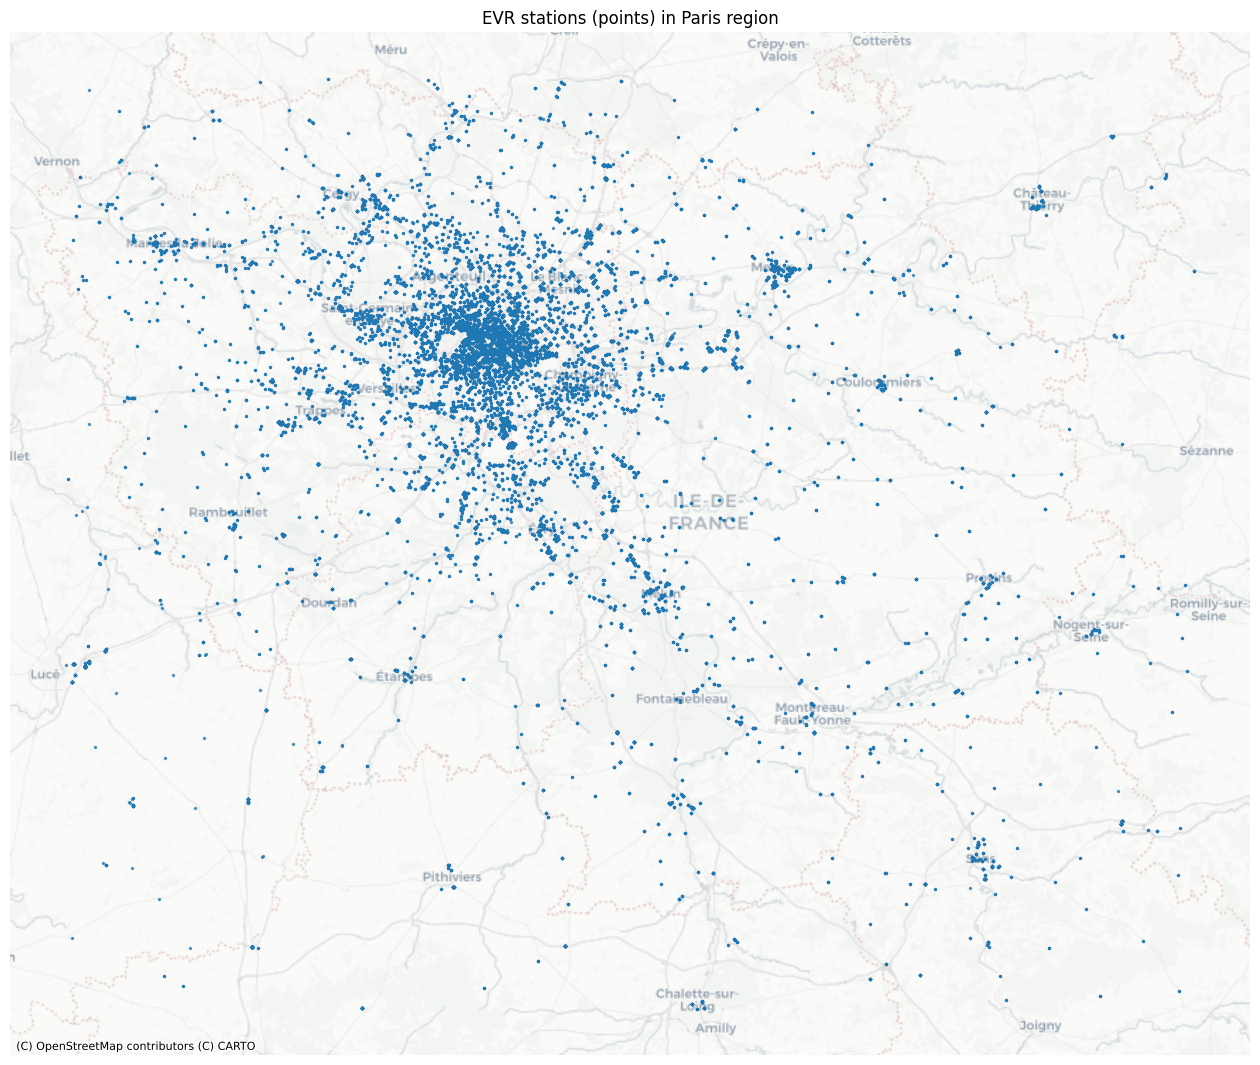

In [8]:
import matplotlib.pyplot as plt
import contextily as cx

ax = gdf.to_crs(3857).plot(figsize=(16,16), markersize=2, alpha=0.7)
cx.add_basemap(ax, crs="EPSG:3857", source=cx.providers.CartoDB.Positron)
ax.set_axis_off()
plt.title("EVR stations (points) in Paris region")
plt.show()

## Filtered map

Filter, e.g., show only recharge station open 24/7.

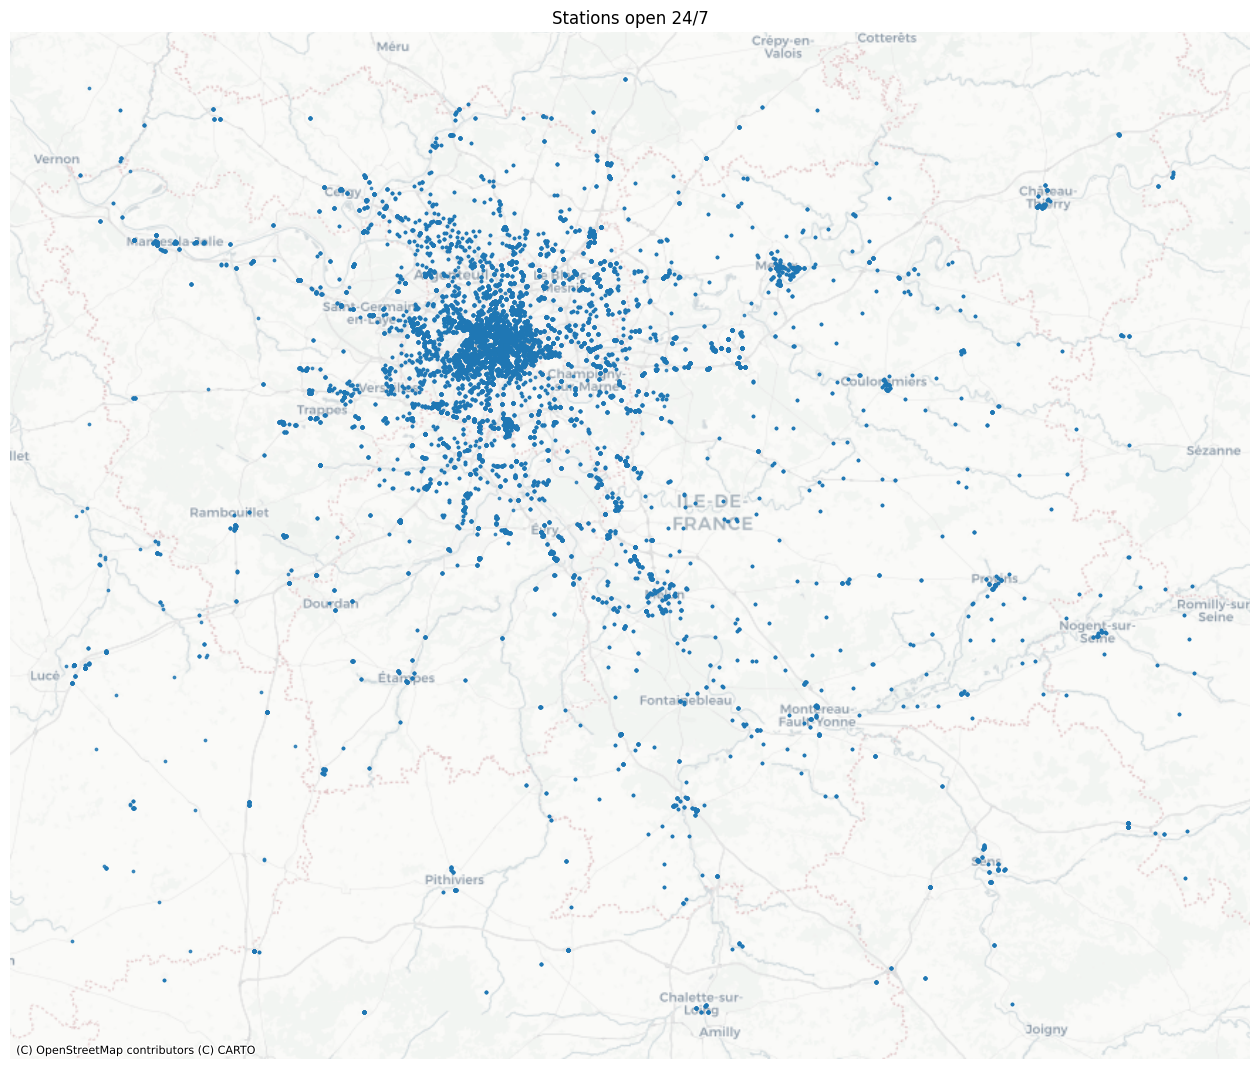

In [9]:
subset = gdf[gdf.get("horaires") == "24/7"]
ax = subset.to_crs(3857).plot(figsize=(16,16), markersize=3, alpha=0.8)
cx.add_basemap(ax, crs="EPSG:3857", source=cx.providers.CartoDB.Positron)
ax.set_axis_off(); plt.title("Stations open 24/7"); plt.show()

# Interactive map

To avoid memory issues, let's only include a part of the points here.
We will trim to 5000 points.

In [10]:
import folium
from folium.plugins import MarkerCluster

# Center roughly on Paris
m = folium.Map(location=[46.5, 2.2], zoom_start=5)
cluster = MarkerCluster().add_to(m)

for _, r in gdf.sample(5000).iterrows():
    if r.geometry and r.geometry.geom_type == "Point":
        lat, lon = r.geometry.y, r.geometry.x
        popup = (f"<b>{r.get('nom_station','')}</b><br>"
                 f"Opérateur: {r.get('nom_operateur','')}<br>"
                 f"Horaires: {r.get('horaires','')}")
        folium.Marker([lat, lon], popup=popup).add_to(cluster)

m